In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder, NonLinearAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.decomposition import PCA

from tqdm.auto import tqdm

from autoencoder import NonLinearAutoencoder
from solver import *
from model_utils import *

In [2]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [3]:
save_path = os.path.expanduser('~/paper_cifar_models/cnn/pca-init-cifar/')
print('save_path:', save_path)
if not os.path.exists(save_path):
    os.makedirs(save_path)

save_path: /home/david/paper_cifar_models/cnn/pca-init-cifar/


In [4]:
# CIFAR10 normalization (RGB channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR10 datasets
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training set into train/validation
train_size = int(len(cifar_train) * 0.8)  # 40,000 samples
validation_size = len(cifar_train) - train_size  # 10,000 samples
cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [train_size, validation_size])

# Create data loaders
batch_size = 128
train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(cifar_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(cifar_test, batch_size=batch_size, shuffle=False, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
def sample_patches(dataloader, n_patches=100_000, kernel_size=3):
    patches = []

    for images, *_ in dataloader:
        B, C, H, W = images.shape

        ys = torch.randint(0, H - kernel_size, (1000,))
        xs = torch.randint(0, W - kernel_size, (1000,))

        for x, y in zip(xs, ys):
            patch = images[:, :, y:y+kernel_size, x:x+kernel_size]
            patches.append(patch.reshape(B, -1))  # (B, 27)

        if len(patches)*B >= n_patches:
            break
    
    P = torch.cat(patches, dim=0)[:n_patches]
    return P.numpy()

In [6]:
patch_matrix = sample_patches(train_loader, n_patches=100_000, kernel_size=3)

(-0.5, 2.5, 2.5, -0.5)

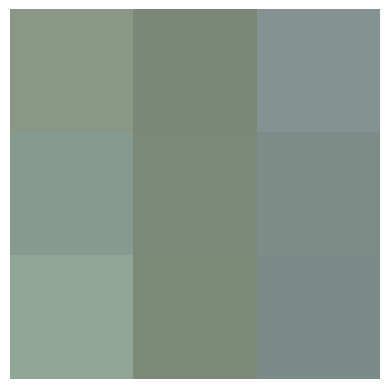

In [7]:
# Denormalize example patch
patch = patch_matrix[100].reshape(3, 3, 3)
mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)
std = np.array([0.2470, 0.2435, 0.2616]).reshape(3, 1, 1)
patch_denorm = patch * std + mean
patch_denorm = np.clip(patch_denorm, 0, 1)

plt.imshow(patch_denorm.transpose(1, 2, 0))
plt.axis('off')

In [8]:
pca = PCA(n_components=27)
pca.fit(patch_matrix)

filters = pca.components_.reshape(27, 3, 3, 3)

In [9]:
sae_model_pca_init = ConvAutoencoder(latent_dim=128)
sae_optimizer = torch.optim.SGD(sae_model_pca_init.parameters(), lr=0.1, momentum=0.9)

with torch.no_grad():
    sae_model_pca_init.encoder[0].weight[:27].copy_(torch.from_numpy(filters))
    sae_model_pca_init.encoder[0].bias.zero_()

In [10]:
def initialize_sae_with_pca():
    patch_matrix = sample_patches(train_loader, n_patches=100_000, kernel_size=3)

    pca = PCA(n_components=27)
    pca.fit(patch_matrix)

    filters = pca.components_.reshape(27, 3, 3, 3)


    sae_model_pca_init = ConvAutoencoder(latent_dim=128)
    sae_optimizer = torch.optim.SGD(sae_model_pca_init.parameters(), lr=0.1, momentum=0.9)

    with torch.no_grad():
        sae_model_pca_init.encoder[0].weight[:27].copy_(torch.from_numpy(filters))
        sae_model_pca_init.encoder[0].bias.zero_()

    return sae_model_pca_init.to(device), sae_optimizer

In [31]:
for i in range(3, 10):
    save_path = os.path.join(os.path.expanduser('~'), 'paper_cifar_models/cnn/pca-init-cifar', str(i))
    os.makedirs(save_path, exist_ok=True)

    sae_model_pca_init, sae_optimizer = initialize_sae_with_pca()

    train_loss, vali_loss = train_vali_all_epochs_conv(
                                                sae_model_pca_init,
                                                train_loader,
                                                validation_loader,
                                                sae_optimizer,
                                                60,
                                                device,
                                                save_path + '/',
                                                )

    np.save(os.path.join(save_path, 'train_loss.npy'), train_loss)
    np.save(os.path.join(save_path, 'vali_loss.npy'), vali_loss)

Train Epoch: 0 [19968/40000 (100%)]	Loss: 0.014337: 100%|██████████| 313/313 [00:03<00:00, 88.44it/s]


====> Epoch: 0 Average loss: 1.0005
====> Test set loss: 3076.0547
Weights saved.


Train Epoch: 1 [19968/40000 (100%)]	Loss: 0.014614: 100%|██████████| 313/313 [00:03<00:00, 83.82it/s]

====> Epoch: 1 Average loss: 1.0000


====> Test set loss: 3073.9067
Weights saved.


...

====> Epoch: 58 Average loss: 0.1702


====> Test set loss: 528.2273
Weights saved.


Train Epoch: 59 [19968/40000 (100%)]	Loss: 0.002691: 100%|██████████| 313/313 [00:05<00:00, 52.85it/s]

====> Epoch: 59 Average loss: 0.1694


====> Test set loss: 523.6705
Weights saved.


In [21]:
train_losses = []
vali_losses = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/cifar_models/sae/', str(i), 'vali_loss.npy'))
    train_losses.append(train_loss_i)
    vali_losses.append(vali_loss_i)

train_losses = np.stack(train_losses)
vali_losses = np.stack(vali_losses)

train_loss_mean = train_losses.mean(axis=0)
train_loss_std = train_losses.std(axis=0)
vali_loss_mean = vali_losses.mean(axis=0)
vali_loss_std = vali_losses.std(axis=0)

In [32]:
train_losses_pca = []
vali_losses_pca = []

for i in range(10):
    train_loss_i = np.load(os.path.expanduser('~') + os.path.join('/paper_cifar_models/cnn/pca-init-cifar/', str(i), 'train_loss.npy'))
    vali_loss_i = np.load(os.path.expanduser('~') + os.path.join('/paper_cifar_models/cnn/pca-init-cifar/', str(i), 'vali_loss.npy'))
    train_losses_pca.append(train_loss_i)
    vali_losses_pca.append(vali_loss_i)

train_losses_pca = np.stack(train_losses_pca)
vali_losses_pca = np.stack(vali_losses_pca)

train_loss_mean_pca = train_losses_pca.mean(axis=0)
train_loss_std_pca = train_losses_pca.std(axis=0)
vali_loss_mean_pca = vali_losses_pca.mean(axis=0)
vali_loss_std_pca = vali_losses_pca.std(axis=0)

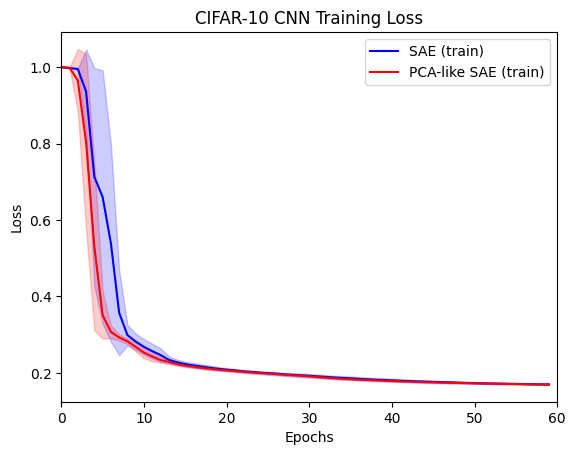

In [37]:
plt.plot(train_loss_mean, label='SAE (train)', color='blue')
plt.fill_between(np.arange(len(train_loss_mean)), train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2, color='blue')
plt.plot(train_loss_mean_pca, label='PCA-like SAE (train)', color='red')
plt.fill_between(np.arange(len(train_loss_mean_pca)), train_loss_mean_pca - train_loss_std_pca, train_loss_mean_pca + train_loss_std_pca, alpha=0.2, color='red')
plt.legend()
plt.title('CIFAR-10 CNN Training Loss')
plt.xlabel('Epochs')
plt.xlim(0, 60)
plt.ylabel('Loss')
plt.show()

In [ ]:
from rf_computation import compute_final_rfs

rfs = compute_final_rfs(model_type='sae-pca-init', dataset='cifar', size_ls=None, num_models=10, num_epochs=60, base_path=os.path.expanduser('~/'))

SAE-PCA-INIT:   0%|          | 0/10 [00:00<?, ?it/s]

/home/david/cifar_models/sae-pca-init/0/model_weights_epoch59.pth


SAE-PCA-INIT:  10%|█         | 1/10 [00:25<03:46, 25.13s/it]

/home/david/cifar_models/sae-pca-init/1/model_weights_epoch59.pth


SAE-PCA-INIT:  20%|██        | 2/10 [00:50<03:24, 25.52s/it]

...

SAE-PCA-INIT:  80%|████████  | 8/10 [03:13<00:47, 23.81s/it]

/home/david/cifar_models/sae-pca-init/8/model_weights_epoch59.pth


SAE-PCA-INIT:  90%|█████████ | 9/10 [03:36<00:23, 23.55s/it]

/home/david/cifar_models/sae-pca-init/9/model_weights_epoch59.pth


SAE-PCA-INIT: 100%|██████████| 10/10 [03:59<00:00, 23.95s/it]


In [18]:
sae_rfs = np.load('Results/cifar_sae_rfs.npy')
sae_rfs.shape

(10, 60, 128, 3, 32, 32)

In [23]:
dae_rfs = np.load('Results/cifar_sae-pca-init_final_rfs.npy')
# Expand to (10, 60, 128, 3, 32, 32) by repeating along new axis
dae_rfs = np.repeat(dae_rfs[:, np.newaxis, :, :, :, :], 60, axis=1)
np.save('Results/cifar_dae_rfs.npy', dae_rfs)

In [11]:
sae_rfs_pca_init = np.load('Results/cifar_sae_rfs.npy')[:, -1, :, :, :, :]
np.save('Results/cifar_dae_rfs.npy', sae_rfs_pca_init)

In [13]:
dae_rfs = np.load('Results/cifar_dae_rfs.npy')
dae_rfs.shape

(10, 128, 3, 32, 32)

In [20]:
from power_spectra import compute_power_spectra

sae_power_spectra, dae_power_spectra = compute_power_spectra(save_path_sae=None, save_path_dae=None, sae_rfs=sae_rfs, dae_rfs=sae_rfs_pca_init, num_models=10, epoch=0)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 27.58it/s]


In [29]:
from power_spectra import plot_power_spectra

plot_power_spectra(model_type='cnn', sae_power_spectra=sae_power_spectra, dae_power_spectra=dae_power_spectra)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


NameError: name 'fig' is not defined

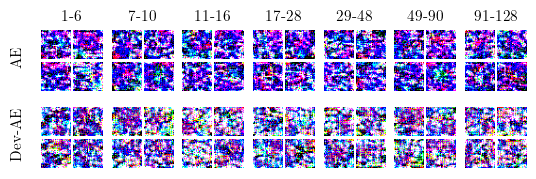

In [25]:
from plot_example_rfs import plot_example_rfs

fig = plt.figure(figsize=(6.26, 1.9))
ax = fig.add_subplot(111)
plot_example_rfs(ax, dataset='cifar', epoch_idx=59)
plt.close(fig)